In [2]:
# Importar librerías
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("/content/student_lifestyle_100k.csv")

df["Department"] = df["Department"].astype(str)

df["Department"] = df["Department"].str.strip().str.lower()

df = pd.get_dummies(df, columns=["Department"], drop_first=False)

df.drop(columns=["Student_ID"], inplace=True)

df["Gender"] = df["Gender"].astype(str)

df["Gender"] = df["Gender"].str.strip().str.lower()

df.loc[df["Gender"] == "male", "Gender"] = 0
df.loc[df["Gender"] == "female", "Gender"] = 1

df["Gender"] = df["Gender"].astype(int)
# Ver primeras filas
print(df.head())



y = df["Depression"]

# X = todas las columnas menos la salida
X = df.drop(columns=["Depression"])



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)



model.fit(X_train, y_train)



score = model.score(X_test, y_test)

print(f'Accuracy: {score:.4f}')



joblib.dump(model, "modelo.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Modelo y scaler guardados correctamente")

   Age  Gender  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   22       1  3.50             7.3          3.3                 3.4   
1   20       0  2.72             5.5          7.2                 6.0   
2   20       0  3.01             5.4          2.3                 1.8   
3   21       0  3.63             8.1          2.0                 4.6   
4   19       0  3.14             6.8          2.6                 4.3   

   Physical_Activity  Stress_Level  Depression  Department_arts  \
0                114             5       False            False   
1                142             2       False            False   
2                137             3       False            False   
3                130             3       False            False   
4                  4             6       False             True   

   Department_business  Department_engineering  Department_medical  \
0                False                   False               False   
1                F

Matriz de confusión:
[[17981    14]
 [ 1989    16]]


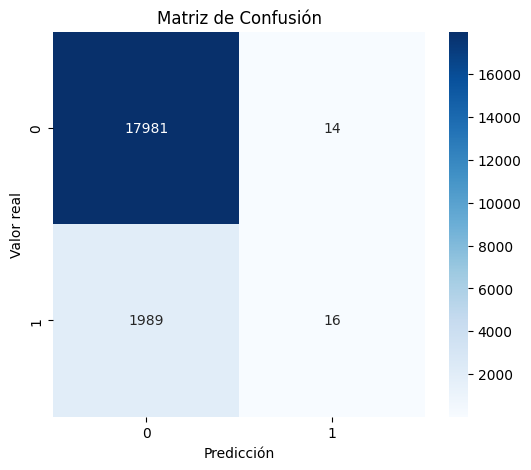


Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     17995
        True       0.53      0.01      0.02      2005

    accuracy                           0.90     20000
   macro avg       0.72      0.50      0.48     20000
weighted avg       0.86      0.90      0.85     20000


Distribución de clases en todo el dataset:
Depression
False    89938
True     10062
Name: count, dtype: int64

Distribución porcentual:
Depression
False    89.938
True     10.062
Name: proportion, dtype: float64


In [ ]:
#falta balancearlo
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(cm)

# Graficar matriz
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nDistribución de clases en todo el dataset:")
print(df["Depression"].value_counts())

print("\nDistribución porcentual:")
print(df["Depression"].value_counts(normalize=True) * 100)